In [ ]:
import numpy as np
import pandas as pd

In [ ]:
RANDOM_STATE = 42
DATASET_PATH = 'data.csv'

In [ ]:
data = pd.read_csv(DATASET_PATH)
data.shape

(1200, 10)

In [ ]:
data.sample(5)

,Unnamed: 0,Month,DayofMonth,DayOfWeek,DepTime,UniqueCarrier,Origin,Dest,Distance,dep_delayed_15min
1022,1274,c-2,c-22,c-3,1800,EV,EVV,ATL,350,Y
981,1024,c-4,c-6,c-4,1814,WN,LAS,BUR,223,Y
658,799,c-8,c-22,c-2,1524,NW,TPA,DTW,983,N
1084,1576,c-2,c-27,c-7,1137,WN,HOU,BNA,670,Y
142,167,c-8,c-30,c-2,1243,MQ,ORD,MKE,67,N


обучим модель на признаках DepTime и Distance

In [ ]:
from sklearn.model_selection import train_test_split

X = data[['DepTime', 'Distance']]
y = pd.get_dummies(data['dep_delayed_15min'], drop_first=True)

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=RANDOM_STATE)
model.fit(Xtrain, ytrain)


DecisionTreeClassifier(random_state=42)

In [ ]:
from sklearn.metrics import roc_auc_score

y_pred_proba = model.predict_proba(Xtest)[:, 1]
roc_auc_score(ytest, y_pred_proba)

np.float64(0.53784109754259)

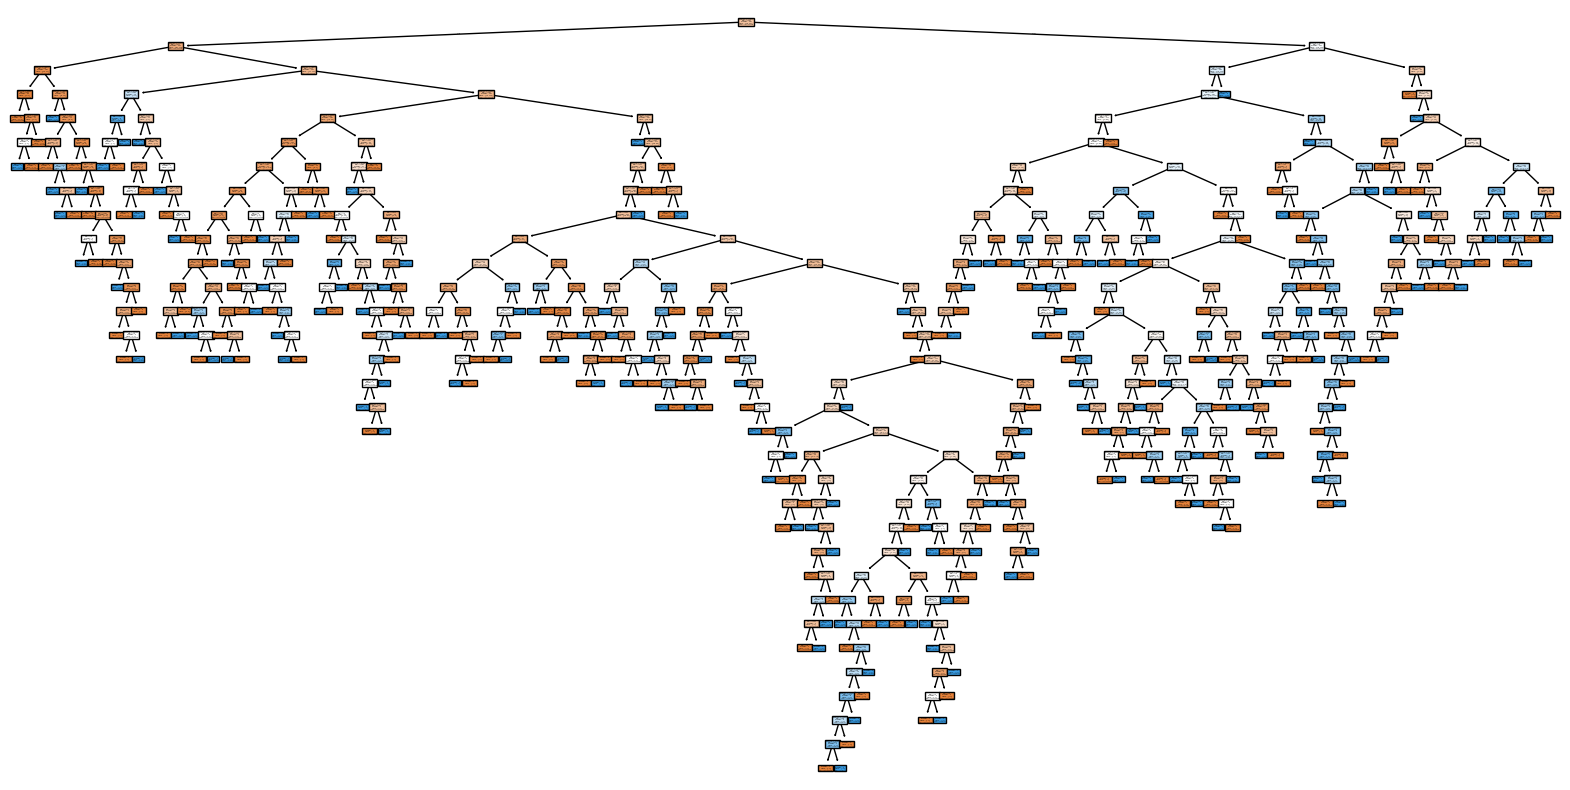

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(model, filled=True, feature_names=['DepTime', 'Distance'], class_names=['Not delayed', 'Delayed'])
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


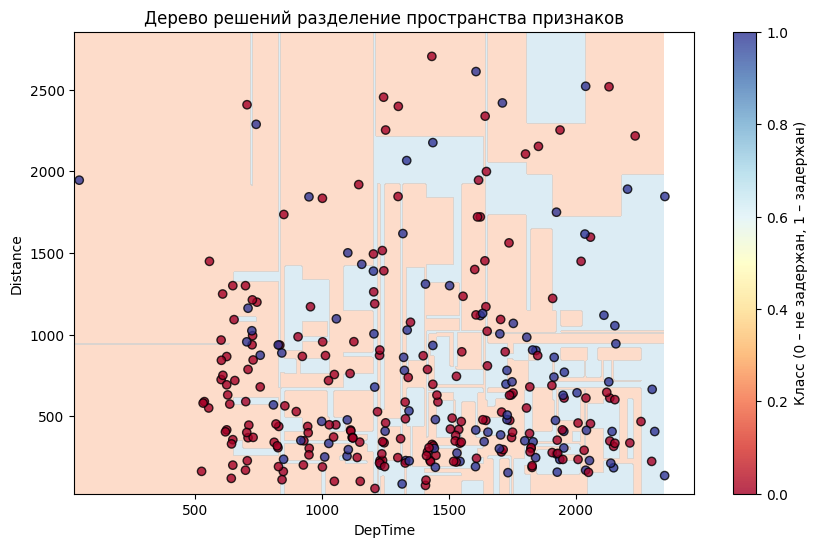

In [ ]:
import matplotlib.pyplot as plt

x_min, x_max = Xtrain['DepTime'].min() - 10, Xtrain['DepTime'].max() + 10
y_min, y_max = Xtrain['Distance'].min() - 10, Xtrain['Distance'].max() + 10
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

def plot_decision_boundary(model, X_test, y_test, title):
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu', levels=[-0.5, 0.5, 1.5])

    scatter = plt.scatter(
        X_test['DepTime'],
        X_test['Distance'],
        c=y_test.values.ravel(),
        cmap='RdYlBu',
        edgecolor='k',
        alpha=0.8,
    )
    plt.xlabel('DepTime')
    plt.ylabel('Distance')
    plt.title(title)
    plt.colorbar(scatter, label='Класс (0 – не задержан, 1 – задержан)')
    plt.show()

plot_decision_boundary(model, Xtest, ytest, 'Дерево решений разделение пространства признаков')

# Ансамбли. Бэггинг

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=RANDOM_STATE)
model.fit(Xtrain, ytrain.values.ravel())

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_proba = model.predict_proba(Xtest)[:, 1]
roc_auc_score(ytest, y_pred_proba)

np.float64(0.6124679632142318)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


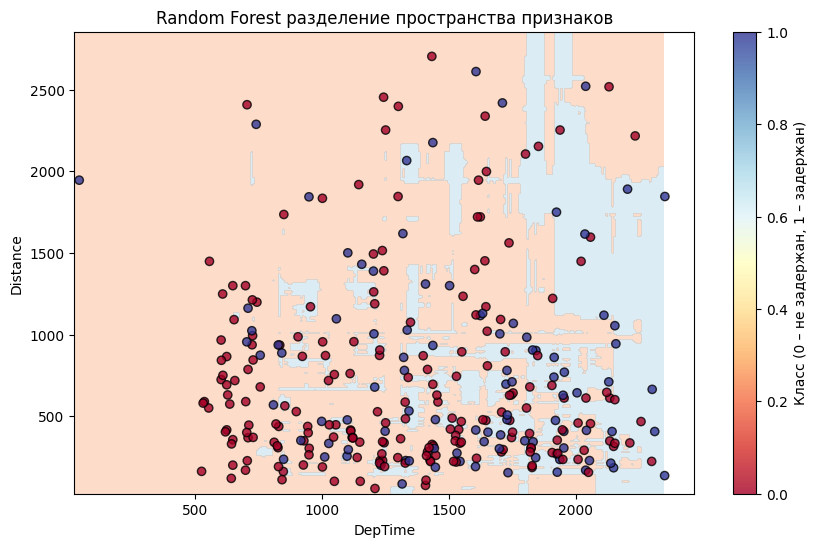

In [ ]:
# Рисуем для случайного леса
plot_decision_boundary(model, Xtest, ytest, 'Random Forest разделение пространства признаков')

# Ансамбли. Бустинг

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(random_state=RANDOM_STATE)
model.fit(Xtrain, ytrain.values.ravel())

GradientBoostingClassifier(random_state=42)

In [ ]:
y_pred_proba = model.predict_proba(Xtest)[:, 1]
roc_auc_score(ytest, y_pred_proba)

np.float64(0.6170159304487662)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


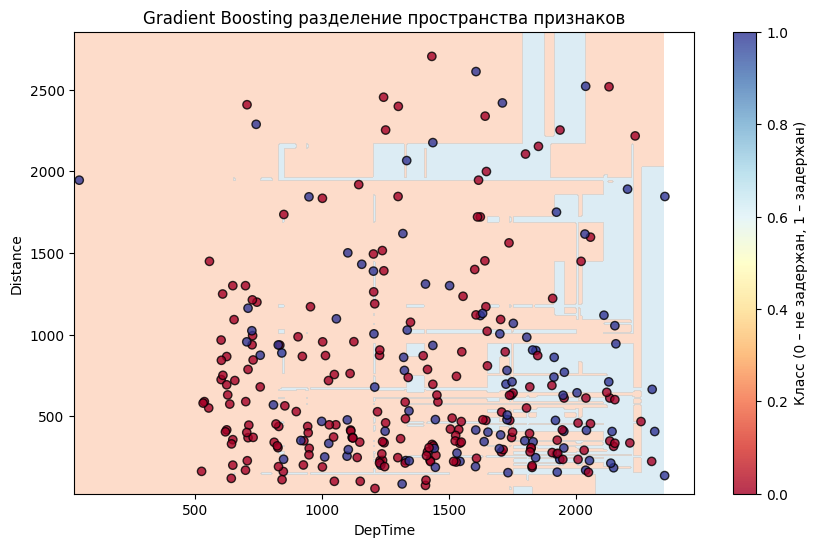

In [ ]:
# Рисуем для градиентного бустинга
plot_decision_boundary(model, Xtest, ytest, 'Gradient Boosting разделение пространства признаков')

In [ ]:
from xgboost import XGBClassifier

# Обучаем XGBoost
model = XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss')
model.fit(Xtrain, ytrain.values.ravel())

y_pred_proba = model.predict_proba(Xtest)[:, 1]
roc_auc_score(ytest, y_pred_proba)

np.float64(0.6191014623850444)

In [ ]:
! pip install catboost

In [ ]:
from catboost import CatBoostClassifier

# Обучаем CatBoost (отключим вывод прогресса)
model = CatBoostClassifier(random_state=RANDOM_STATE, verbose=0)
model.fit(Xtrain, ytrain.values.ravel())

y_pred_proba = model.predict_proba(Xtest)[:, 1]
roc_auc_score(ytest, y_pred_proba)

np.float64(0.6428966279712549)

In [ ]:
from lightgbm import LGBMClassifier

# Обучаем LightGBM
model = LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)
model.fit(Xtrain, ytrain.values.ravel())


y_pred_proba = model.predict_proba(Xtest)[:, 1]
roc_auc_score(ytest, y_pred_proba)

np.float64(0.5949293934368561)